# 00 · 개요와 최종 결과

**KP20k 키프레이즈 추출·생성 — GERD 파이프라인.** 학술 문서(제목+초록)에서 저자 키프레이즈를 예측한다.

> ⚠️ **이 노트북들은 파이프라인 코드(`scripts/`, `src/`)와 정합한다.** 학습·추론은 `scripts/`가 수행하고,
> 노트북은 **같은 `src` 모듈을 import**하고 **`results/`에 저장된 실제 결과를 로드**해 보여준다.
> 따라서 여기 나오는 수치는 리포트값(test 20,000편, 전체 데이터 학습)과 정확히 일치한다.

```
문서(제목+초록)
   ├─ Generate : KeyBART seq2seq 로 키프레이즈 생성 (absent 포함)
   ├─ Extract  : KeyBERT 로 본문 구절 추출 (present)
   ├─ Rank     : 후보 병합 → cross-encoder(+aux) 로 관련도 채점
   └─ Diversify: MMR 로 중복 제거 → top-K
```

노트북 순서: **00 결과 → 01 데이터·평가 → 02 베이스라인·하이브리드 → 03 리랭커 → 04 토너먼트·앙상블.**

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings("ignore")

# repo 루트 자동 탐색 (results/ 가 있는 곳) — 노트북을 어디서 열든 동작
ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))            # src.* import 가능
sys.path.insert(0, str(ROOT / "scripts"))  # 스크립트 모듈 import 가능
print("repo root:", ROOT)

repo root: C:\Users\wodlf\OneDrive\Desktop\kp20k-keyphrase-extraction


In [2]:
# 전 모델 통합 지표표 (scripts/encoder_tournament.py --stage grand 산출)
grand = pd.read_csv(ROOT / "results/metrics/grand_comparison_all_models.csv")
# 메인 비교는 베이스라인 vs P7. 앙상블(채점표)과 토너먼트 단일 모델(채점표 재료)은 제외.
SCORECARD = ["P13_ensemble_full", "P16_team_ensemble_full"]          # 채점표(앙상블)
INGREDIENTS = ["P8_full", "P10_full", "P11_full", "P12_full", "P15_full"]  # 채점표 재료
comp = grand[~grand.run_id.isin(SCORECARD + INGREDIENTS)]
cols = ["run_id", "model", "F1@5", "F1@10", "present_F1@5", "absent_R@10", "nDCG@10"]
print("메인 모델 비교 — 베이스라인 + P7의 gold-F1 (채점표·재료는 제외):")
comp[cols].sort_values("F1@5", ascending=False).reset_index(drop=True)

메인 모델 비교 — 베이스라인 + P7의 gold-F1 (채점표·재료는 제외):


,run_id,model,F1@5,F1@10,present_F1@5,absent_R@10,nDCG@10
0,P7_scibert_hybrid_full,SciBERT Hybrid Ranker,0.2850,0.2621,0.3619,0.0504,0.3975
1,P2_hybrid_fusion_mmr_full,Hybrid+MMR,0.2560,0.2105,0.3420,0.0219,0.3429
2,B3_bart_beam5_full,BART,0.2445,0.1711,0.3039,0.0132,0.3088
3,P5_pairwise_full,Hybrid+Pairwise,0.2388,0.2479,0.3109,0.0460,0.3396
4,B4_keybart_beam5_full,KeyBART,0.2377,0.1672,0.2965,0.0097,0.3111
5,N1_notebook_zeroshot_te2000,"2차 노트북 (SciBERT+aux, KeyBART zeroshot)",0.2290,0.1998,0.2966,0.0334,0.3156
6,P6_pairwise_prmu_full,Hybrid+Pairwise(PRMU-w),0.2267,0.2443,0.2980,0.0494,0.3246
7,P1_hybrid_fusion_full,Hybrid,0.2070,0.1842,0.3137,0.0323,0.3012
8,B0_tfidf_full,TF-IDF,0.1261,0.1142,0.1734,0.0113,0.1770
9,B1_keybert_full,KeyBERT,0.0502,0.0601,0.1369,0.0060,0.0767


### F1@5 성능 (메인 모델 — 베이스라인 vs P7)

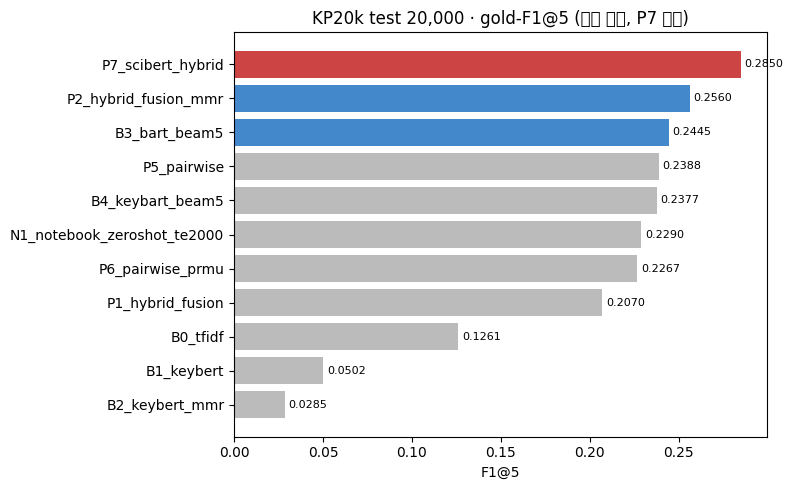

In [3]:
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"] = False

d = comp.sort_values("F1@5")   # 채점표·재료 제외, 메인 모델만
labels = d["run_id"].str.replace("_full", "", regex=False)
colors = ["#c44" if v >= 0.28 else ("#48c" if v >= 0.24 else "#bbb") for v in d["F1@5"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, d["F1@5"], color=colors)
ax.set_xlabel("F1@5"); ax.set_title("KP20k test 20,000 · gold-F1@5 (메인 모델, P7 최고)")
for y, v in enumerate(d["F1@5"]):
    ax.text(v + 0.002, y, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

### 앙상블 = 채점표 (정답 기준)

토너먼트 단일 모델(P8~P15)과 그 RRF 앙상블은 **메인 비교에서 제외**했다 — 앙상블은 F1 경쟁 모델이
아니라 **다른 모델을 채점하는 채점표**이고, P8~P15는 그 재료이기 때문이다.
앙상블 채점표로 채점하면 **P7이 문서 85%에서 KeyBART 베이스라인을 압도**
(nDCG@10 0.898 vs 0.784) — P7이 채점표를 가장 잘 재현하는 단일 모델. (노트북 05, `../docs/ENSEMBLE_REFERENCE_COMPARISON.md`)

### 핵심 발견

1. **P7(SciBERT 하이브리드 리랭커)이 최고 단일 모델** — 성능의 원천은 인코더가 아니라 방법론(aux 3피처 + PRMU 가중 pairwise). (인코더 교체 실험은 채점표 재료 기록: `../docs/ENCODER_TOURNAMENT_STATUS.md`.)
2. **앙상블 = 채점표**: 4개 LLM 리랭커의 RRF 합의를 정답 기준으로 삼아 P7·베이스라인을 채점 → P7 우세.
3. **exact-F1 순위 ≠ 검색 유용성 순위** — "무엇에 쓸 시스템인가"가 최적 모델을 결정한다.

모델별 코드·기법 매핑: [`../MODEL_CATALOG.md`](../MODEL_CATALOG.md).